<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/GGPLOT2_A_Complete_step_by_step_guide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **GGPLOT2 - একটি পূর্ণাঙ্গ ধাপে ধাপে গাইড**

## **১. দ্য গ্রামার অফ গ্রাফিক্স (The Grammar of Graphics)**

`ggplot2` মূলত কতগুলো লেয়ারের ওপর ভিত্তি করে কাজ করে। একটি পূর্ণাঙ্গ গ্রাফ তৈরি করতে নিচের উপাদানগুলো প্রয়োজন:

1. **Data:** আপনার আসল ডেটাসেট।
2. **Mapping (Aesthetics):** কোন ভ্যারিয়েবল কোন অক্ষ (x, y) বা রঙে (color) বসবে।
3. **Geometric Objects (Geoms):** ডেটা কীভাবে দেখা যাবে (বিন্দু, লাইন বা বার)।
4. **Statistics:** ডেটার ওপর ভিত্তি করে স্ট্যাটিস্টিক্যাল ক্যালকুলেশন (যেমন: Mean, Median)।
5. **Facets:** ডেটাকে ছোট ছোট প্যানেলে ভাগ করা।
6. **Themes:** গ্রাফের স্টাইল বা সাজসজ্জা।
7. **Labs:** শিরোনাম এবং লেবেল।

### প্রয়োজনীয় লাইব্রেরি (Required Libraries)

In [ ]:
# install.packages("tidyverse")
library(tidyverse)

### লাইন গ্রাফ (Line Graphs)
ডেটা এক পলকে দেখে নিন (A Quick Look at the Data)

In [ ]:
#data()
?women

women                 package:datasets                 R Documentation

_A_v_e_r_a_g_e _H_e_i_g_h_t_s _a_n_d _W_e_i_g_h_t_s _f_o_r _A_m_e_r_i_c_a_n _W_o_m_e_n

_D_e_s_c_r_i_p_t_i_o_n:

     This data set gives the average heights and weights for American
     women aged 30-39.

_U_s_a_g_e:

     women
     
_F_o_r_m_a_t:

     A data frame with 15 observations on 2 variables.

       ‘[,1]’  ‘height’  numeric  Height (in)  
       ‘[,2]’  ‘weight’  numeric  Weight (lbs) 
      
_D_e_t_a_i_l_s:

     The data set appears to have been taken from the American Society
     of Actuaries _Build and Blood Pressure Study_ for some (unknown to
     us) earlier year.

     The World Almanac notes: “The figures represent weights in
     ordinary indoor clothing and shoes, and heights with shoes”.

_S_o_u_r_c_e:

     The World Almanac and Book of Facts, 1975.

_R_e_f_e_r_e_n_c_e_s:

     McNeil, D. R. (1977) _Interactive Data Analysis_.  Wiley.

_E_x_a_m_p_l_e_s:

     require(graphics)
     plot(women, xlab = "Height (in)", ylab = "Weight (lb)",
          main = "women data: American women aged 30-39")

In [ ]:
View(women)

height,weight
<dbl>,<dbl>
58,115
59,117
60,120
61,123
62,126
63,129
64,132
65,135
66,139


## **১. লাইন গ্রাফ (Line Graphs)**

#### টাইপ - ১.এ (Basic Mapping)
এখানে আমরা শুধু ডেটা এবং এক্সিস ম্যাপিং করেছি।

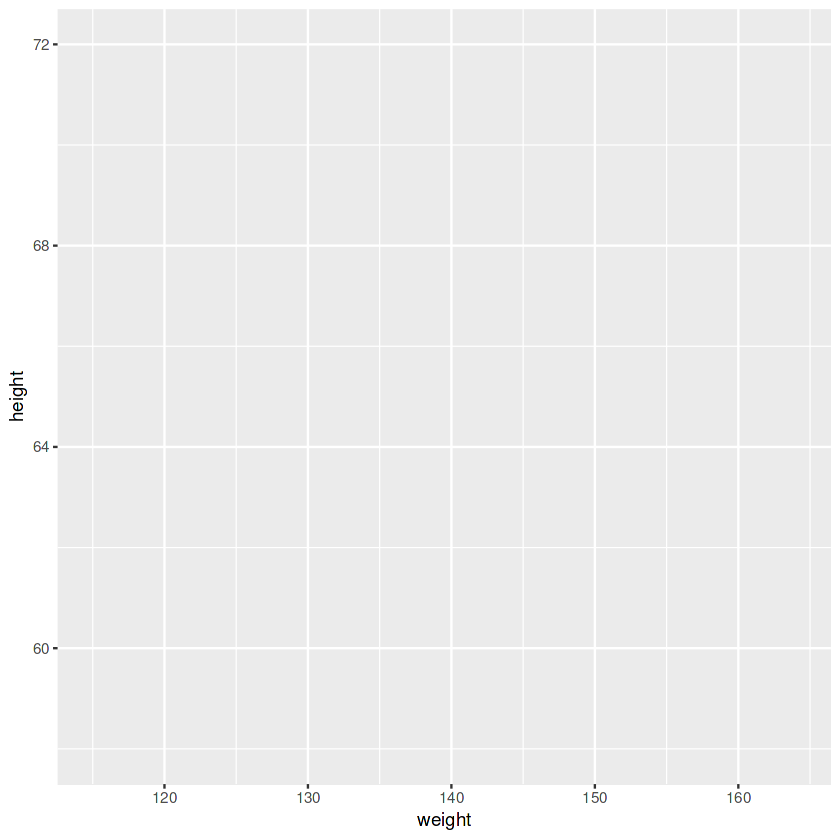

In [ ]:
ggplot(data = women,
       mapping = aes(x = weight,
                     y = height))

#### এখন এতে লাইন এবং বিন্দু যোগ করি:

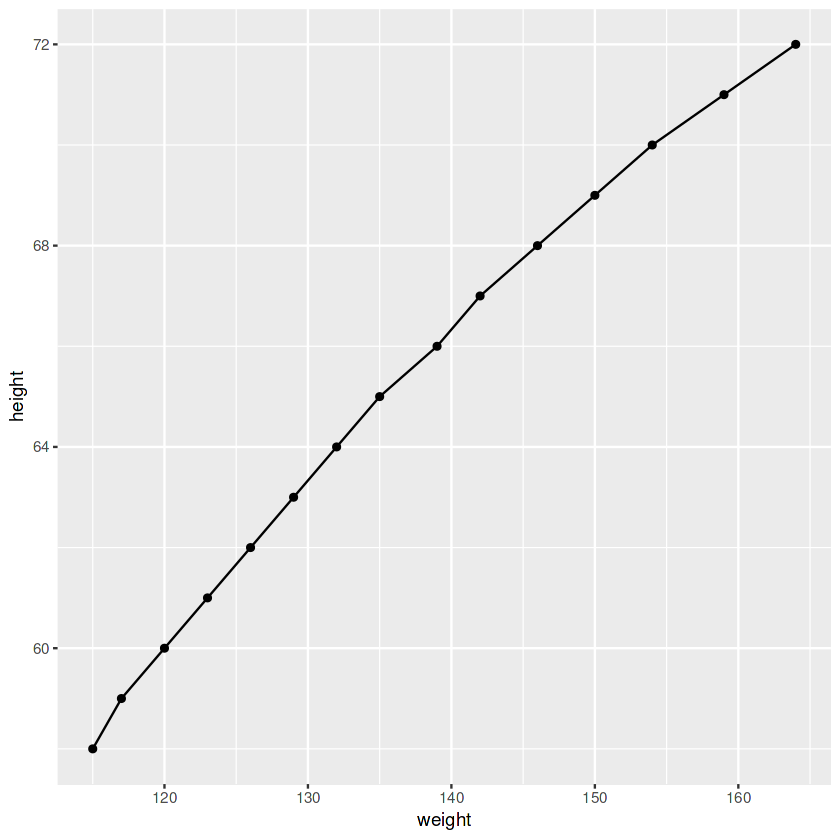

In [ ]:
ggplot(data = women,
       mapping = aes(x = weight,
                     y = height)) +
  geom_point() +
  geom_line()

#### টাইপ - ১.বি (Shortened Syntax)

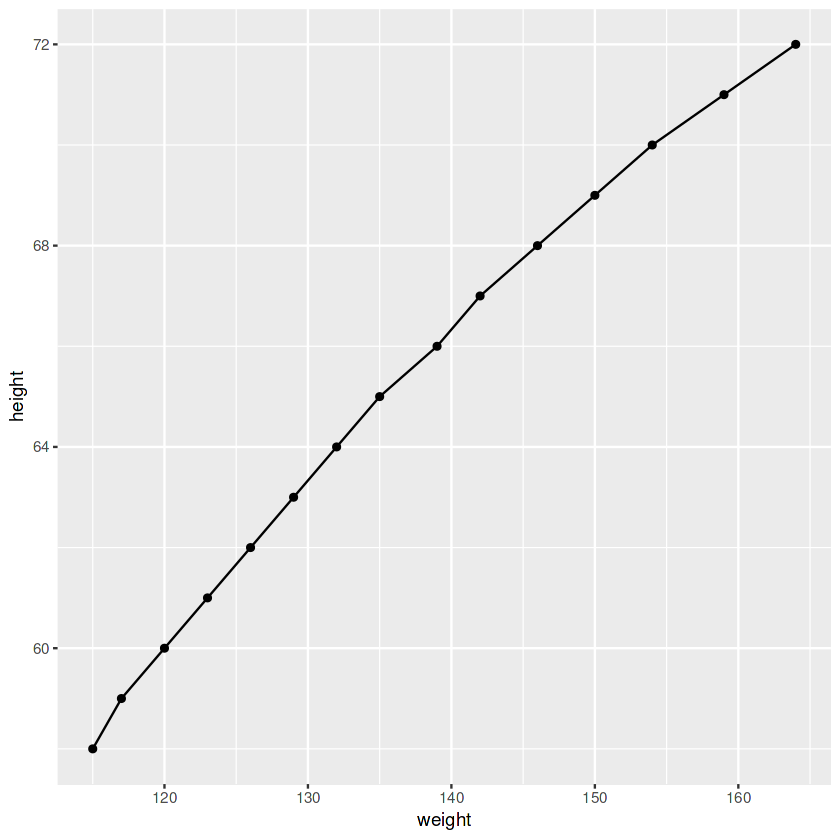

In [ ]:
ggplot(women, aes(weight, height)) +
  geom_point() +
  geom_line()

#### টাইপ - ১.সি (Using Pipes %>%)

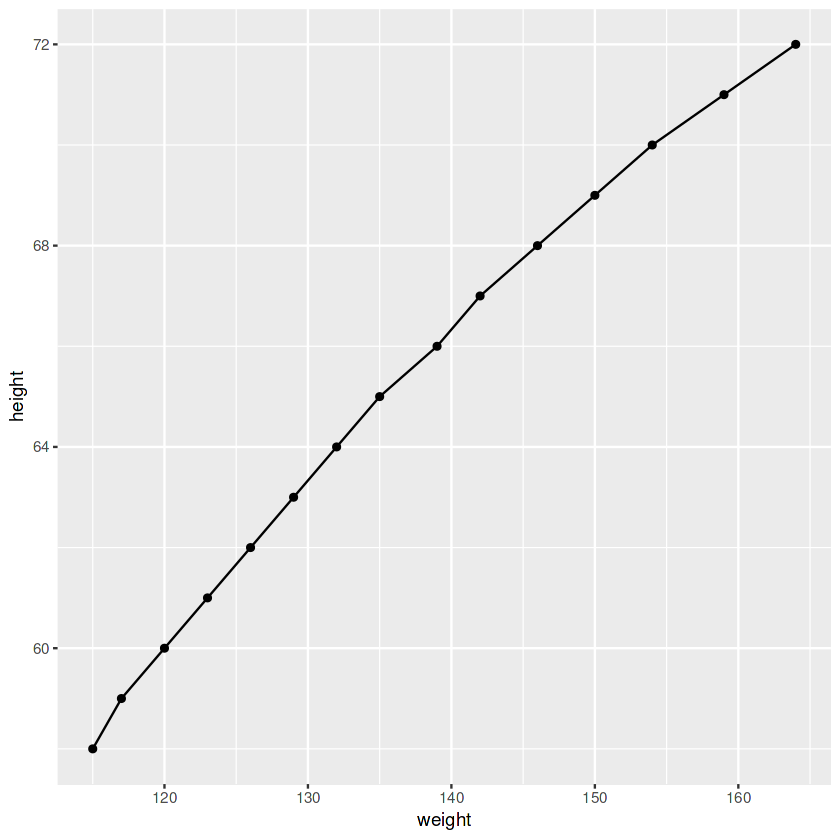

In [ ]:
women %>%
  ggplot(aes(weight, height)) +
  geom_point() +
  geom_line()

#### কাস্টমাইজেশন (Customization)

লাইন গ্রাফ (Line Graphs): সময়ের সাথে পরিবর্তন

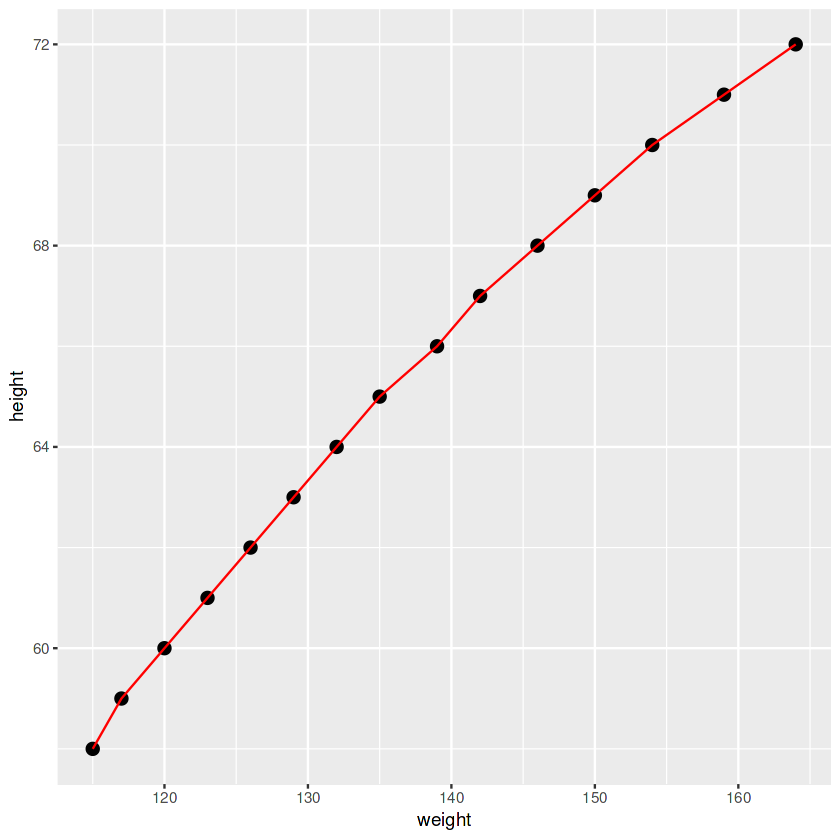

In [ ]:
women %>%
  ggplot(aes(weight, height)) +
  geom_point(size = 3) +
  geom_line(color = "red")

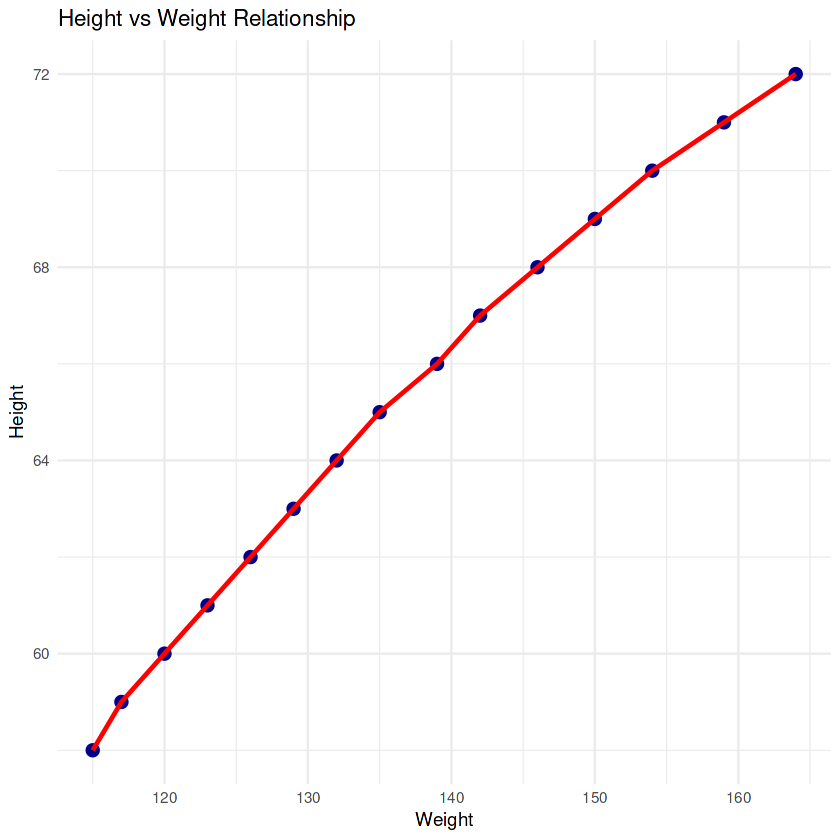

In [ ]:
# পাইপিং (Piping) ব্যবহার করে আধুনিক পদ্ধতি
women %>%
  ggplot(aes(x = weight, y = height)) +
  geom_point(size = 3, color = "darkblue") + # পয়েন্ট যোগ করা
  geom_line(color = "red", linewidth = 1) +  # লাইন যোগ করা
  labs(title = "Height vs Weight Relationship",
       x = "Weight", y = "Height") +
  theme_minimal()

> **টিপস:** সবসময় `geom_point()` এর সাথে `geom_line()` ব্যবহার করুন, এতে প্রতিটি ডেটা পয়েন্টের সঠিক অবস্থান বোঝা যায়।

## **২. বক্সপ্লট (Box Plots): ডেটার ডিস্ট্রিবিউশন**

বক্সপ্লট আমাদের বলে দেয় ডেটার মধ্যে আউটলায়ার আছে কি না এবং ডেটা কতটা ছড়িয়ে আছে।

In [ ]:
#view(chickwts)
names(chickwts)

[1] "weight" "feed"

#### ধাপ ১: সাধারণ বক্সপ্লট

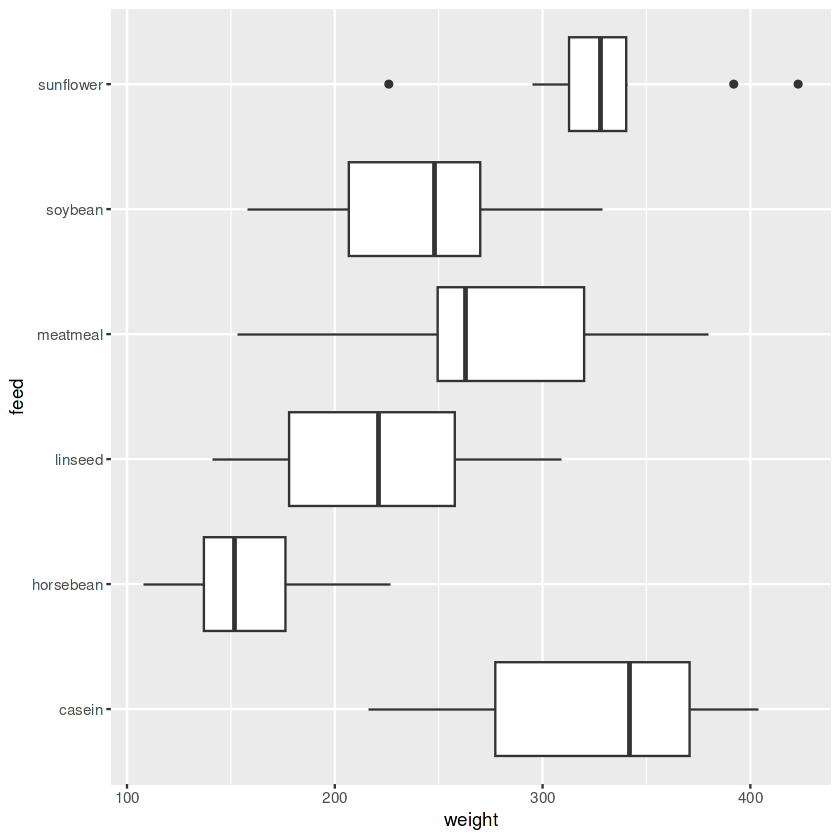

In [ ]:
chickwts %>%
  ggplot(aes(weight, feed)) +
  geom_boxplot()

#### ধাপ ২: রঙ এবং স্বচ্ছতা যোগ করা

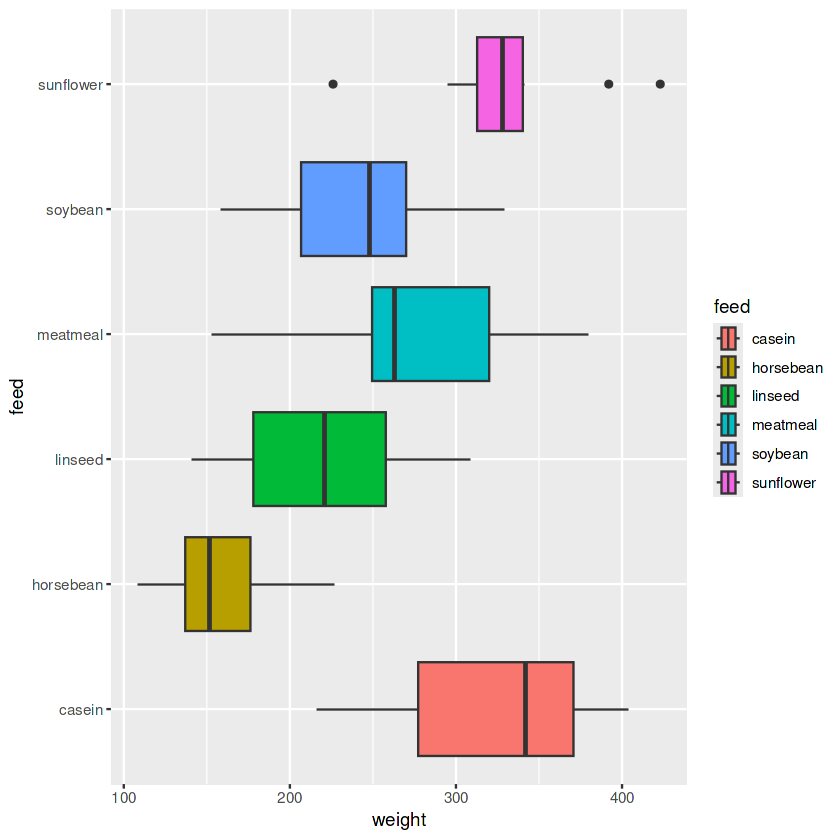

In [ ]:
chickwts %>%
  ggplot(aes(weight, feed,
             fill = feed)) +
  geom_boxplot()

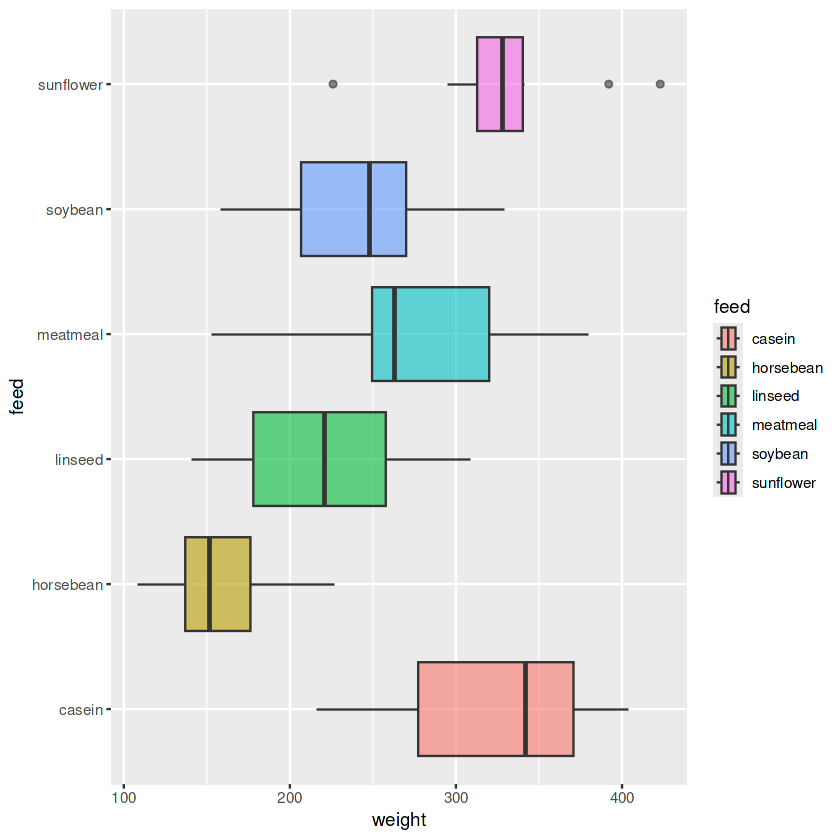

In [ ]:
chickwts %>%
  ggplot(aes(weight, feed,
             fill = feed)) +
  geom_boxplot(alpha = 0.6) # রঙের স্বচ্ছতা বাড়ানো

#### ধাপ ৩: থিম এবং লেবেল যোগ করা

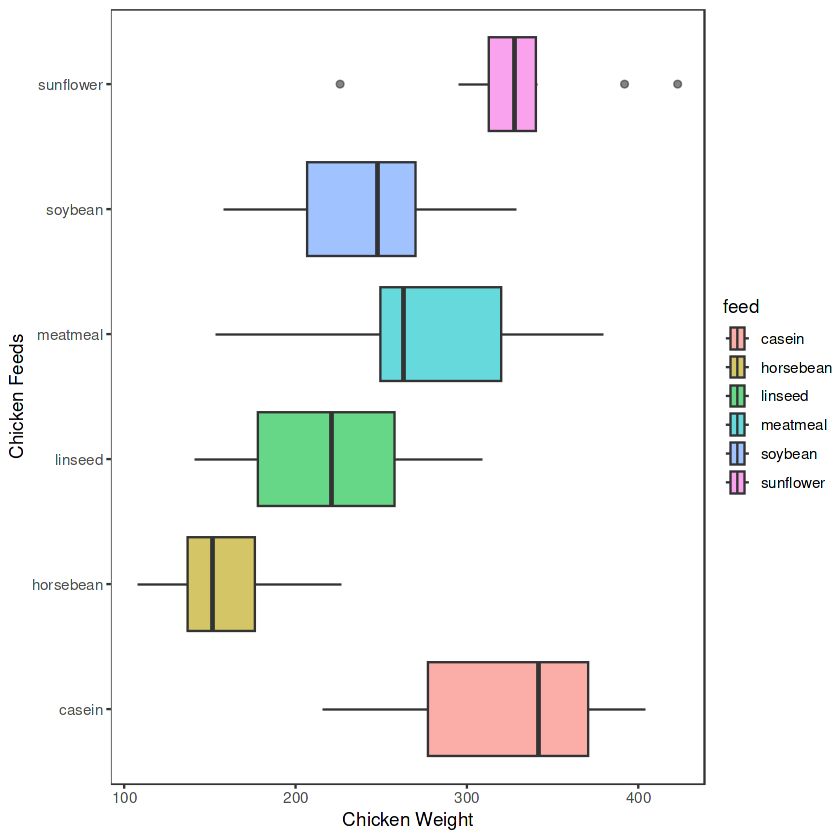

In [ ]:
chickwts %>%
  ggplot(aes(weight, feed, fill = feed)) +
  geom_boxplot(alpha = 0.6) +
  theme_test() +
  labs(x = "Chicken Weight",
       y = "Chicken Feeds")

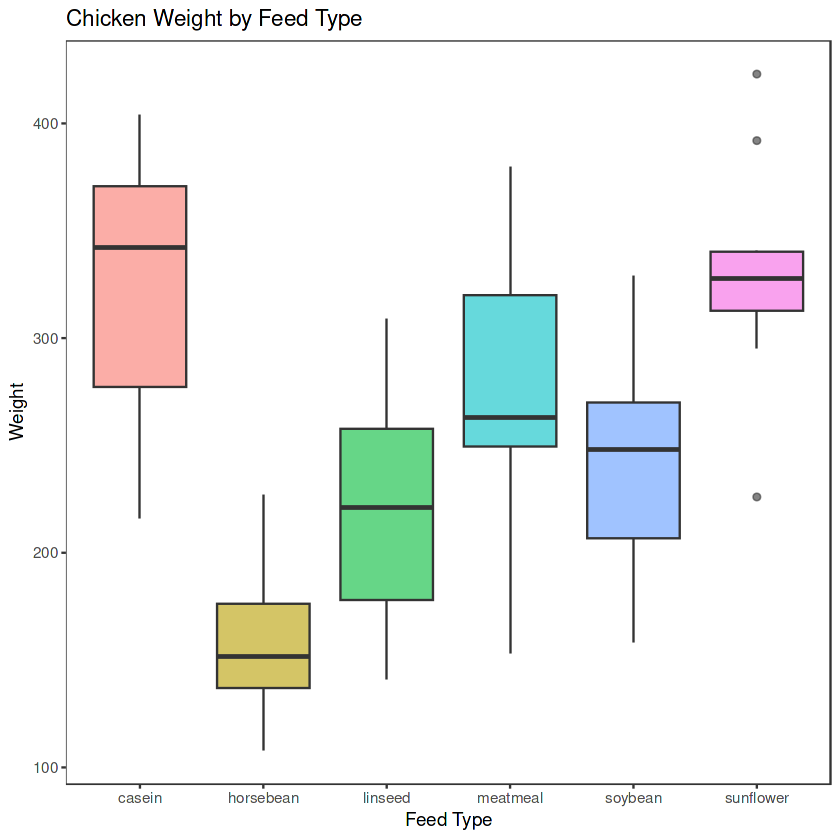

In [ ]:
chickwts %>%
  ggplot(aes(x = feed, y = weight, fill = feed)) +
  geom_boxplot(alpha = 0.6) + # রঙের স্বচ্ছতা বাড়ানো
  theme_test() +
  labs(title = "Chicken Weight by Feed Type",
       x = "Feed Type", y = "Weight") +
  theme(legend.position = "none") # আলাদা লেজেন্ডের প্রয়োজন নেই

## **৩. বার চার্ট (Bar Chart): ক্যাটাগরি গণনা**

বার চার্ট সাধারণত কোনো ক্যাটাগরিক্যাল ডেটার সংখ্যা বা ফ্রিকোয়েন্সি দেখাতে ব্যবহৃত হয়।

#### ডেটা এক পলকে দেখে নিন

In [ ]:
#View(starwars)
names(starwars)

[1] "name"       "height"     "mass"       "hair_color" "skin_color"
 [6] "eye_color"  "birth_year" "sex"        "gender"     "homeworld" 
[11] "species"    "films"      "vehicles"   "starships"

#### ধাপ ১: সাধারণ বার চার্ট

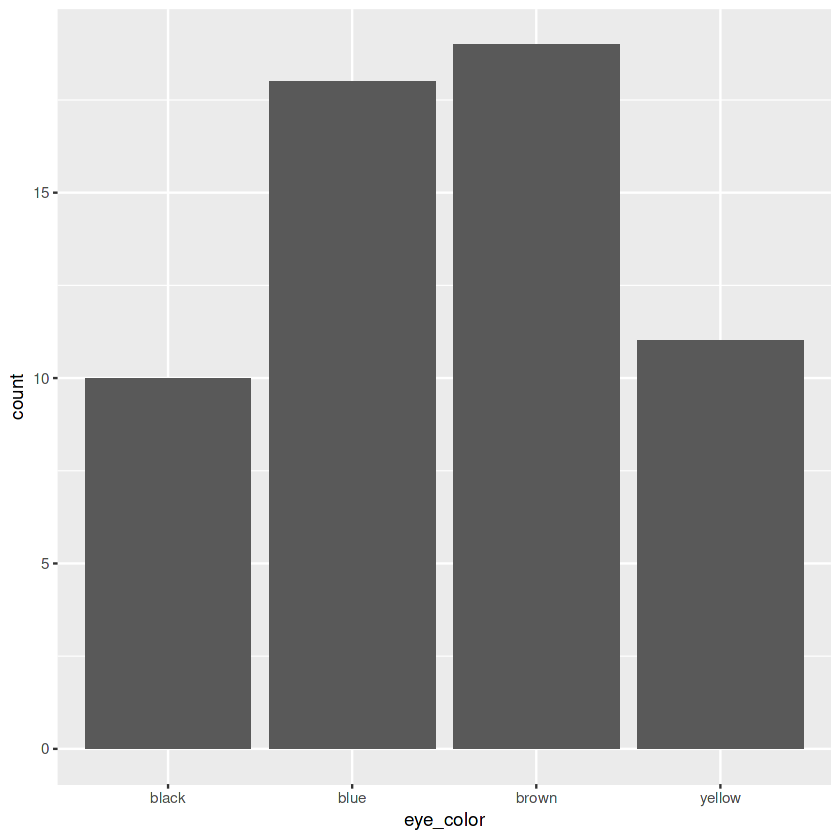

In [ ]:
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color)) +
  geom_bar()

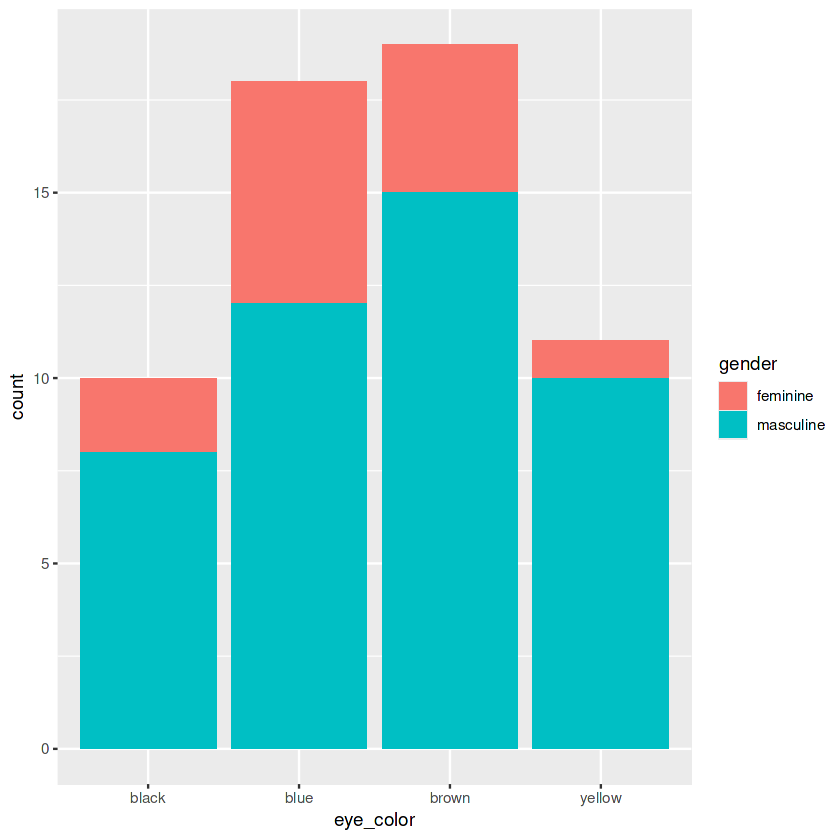

In [ ]:
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color, fill = gender)) +
  geom_bar()

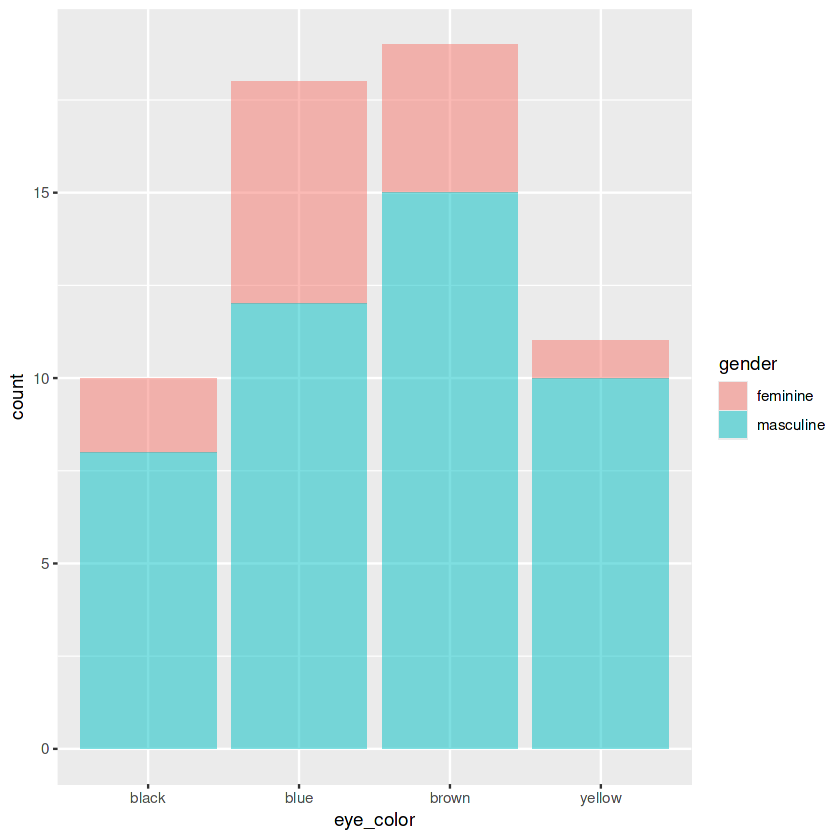

In [ ]:
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color, fill = gender)) +
  geom_bar(alpha = .5) # রঙের স্বচ্ছতা বাড়ানো

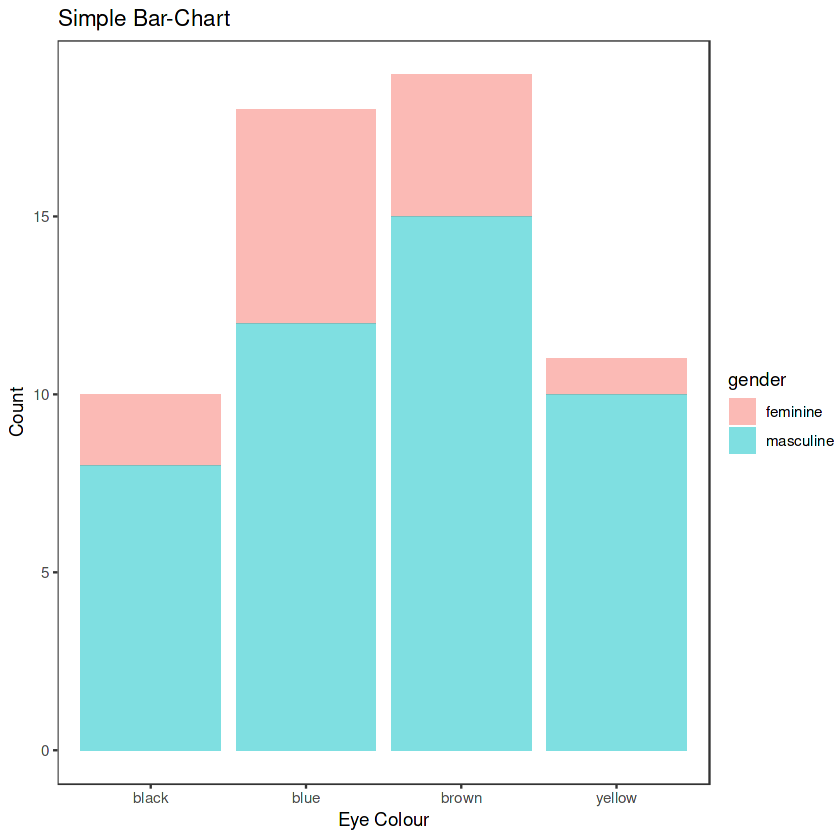

In [ ]:
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color, fill = gender)) +
  geom_bar(alpha = .5) +
  theme_test() +
  labs(title = "Simple Bar-Chart",
       x = "Eye Colour",
       y = "Count")

#### ধাপ ২: স্ট্যাকড বার চার্ট (Stacked Bar-Chart)

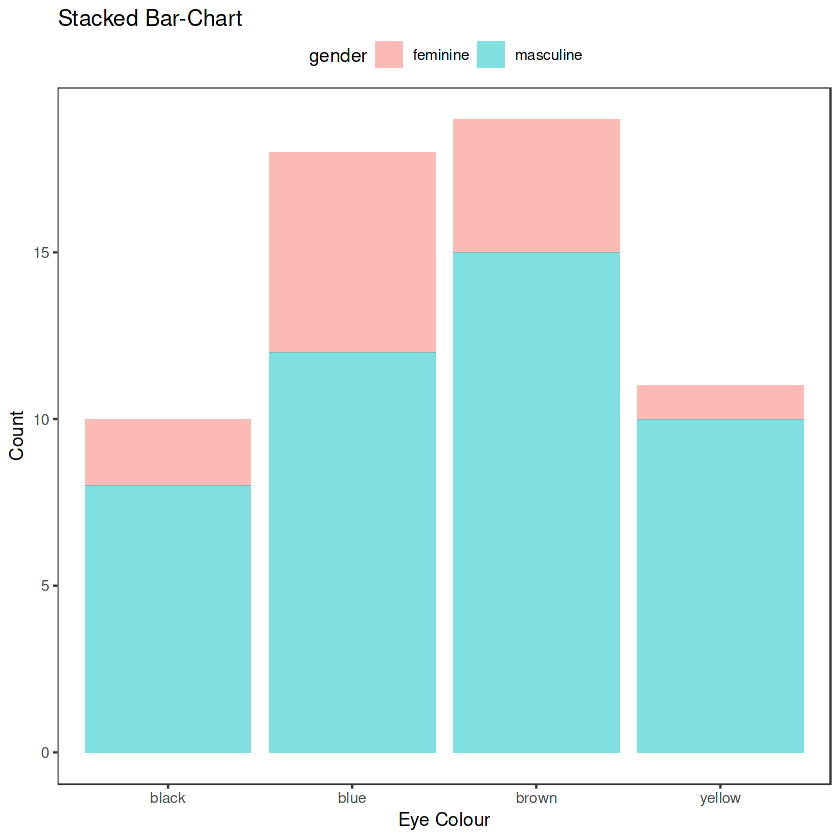

In [ ]:
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color, fill = gender)) +
  geom_bar(stat = "count", alpha = .5) +
  theme_test() +
  labs(title = "Stacked Bar-Chart",
       x = "Eye Colour",
       y = "Count") +
  theme(legend.position = "top")

#### ধাপ ৩: গ্রুপড বার চার্ট (Grouped Bar-Chart)

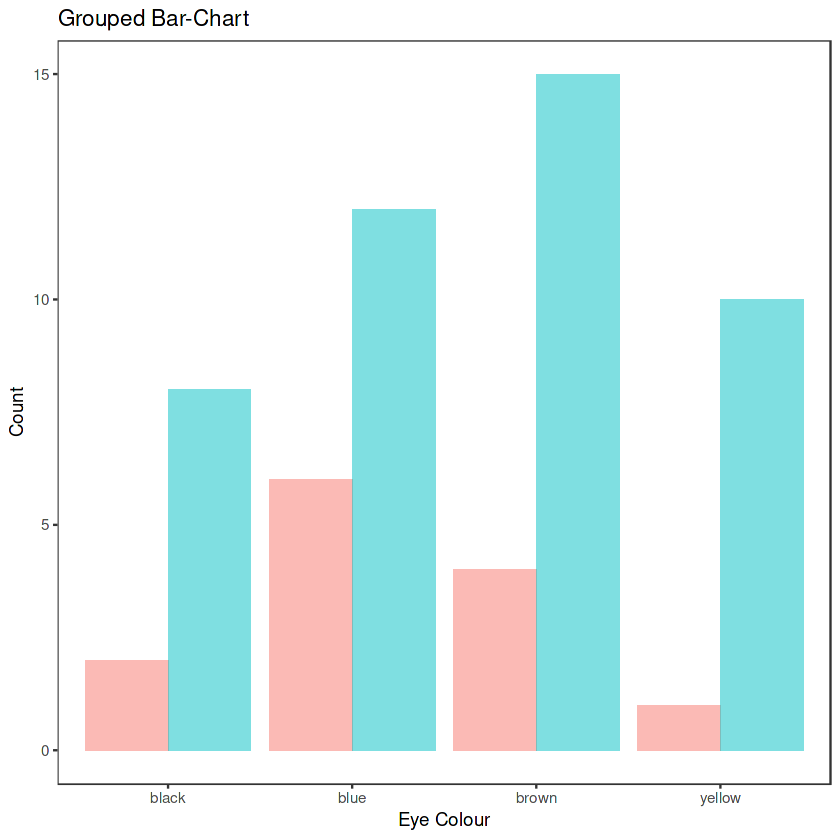

In [ ]:
# গ্রুপড বার চার্ট (Dodge Position)
starwars %>%
  drop_na(eye_color, gender) %>%
  filter(eye_color %in% c("black", "brown",
                          "blue", "yellow")) %>%
  ggplot(aes(eye_color, fill = gender)) +
  geom_bar(stat = "count", alpha = 0.5,
           position = "dodge",
           show.legend = FALSE) +
  theme_test() +
  labs(title = "Grouped Bar-Chart",
       x = "Eye Colour",
       y = "Count")

**পার্থক্য:** `position = "stack"` ব্যবহার করলে বারগুলো একটির ওপর আরেকটি থাকে, আর `position = "dodge"` ব্যবহার করলে তারা পাশাপাশি বসে তুলনা সহজ করে দেয়।

## **৪. স্ক্যাটার প্লট (Scatter Plot): সম্পর্কের বিশ্লেষণ**

এটি `ggplot2` এর সবচেয়ে শক্তিশালী অংশ। এখানে আমরা `gapminder` ডাটাসেট ব্যবহার করে একই সাথে ৪-৫টি ভ্যারিয়েবল দেখাব।

### ফুল গ্রামার অফ গ্রাফিক্স উদাহরণ:

#### প্রয়োজনীয় লাইব্রেরি

In [ ]:
install.packages('gapminder')
library(gapminder)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



#### ডেটা এক পলকে দেখে নিন

In [ ]:
#View(gapminder)
head(gapminder, 8)

country,continent,year,lifeExp,pop,gdpPercap
<fct>,<fct>,<int>,<dbl>,<int>,<dbl>
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530
Afghanistan,Asia,1962,31.997,10267083,853.1007
Afghanistan,Asia,1967,34.020,11537966,836.1971
Afghanistan,Asia,1972,36.088,13079460,739.9811
Afghanistan,Asia,1977,38.438,14880372,786.1134
Afghanistan,Asia,1982,39.854,12881816,978.0114
Afghanistan,Asia,1987,40.822,13867957,852.3959


#### ধাপ ১: বেসিক প্লট

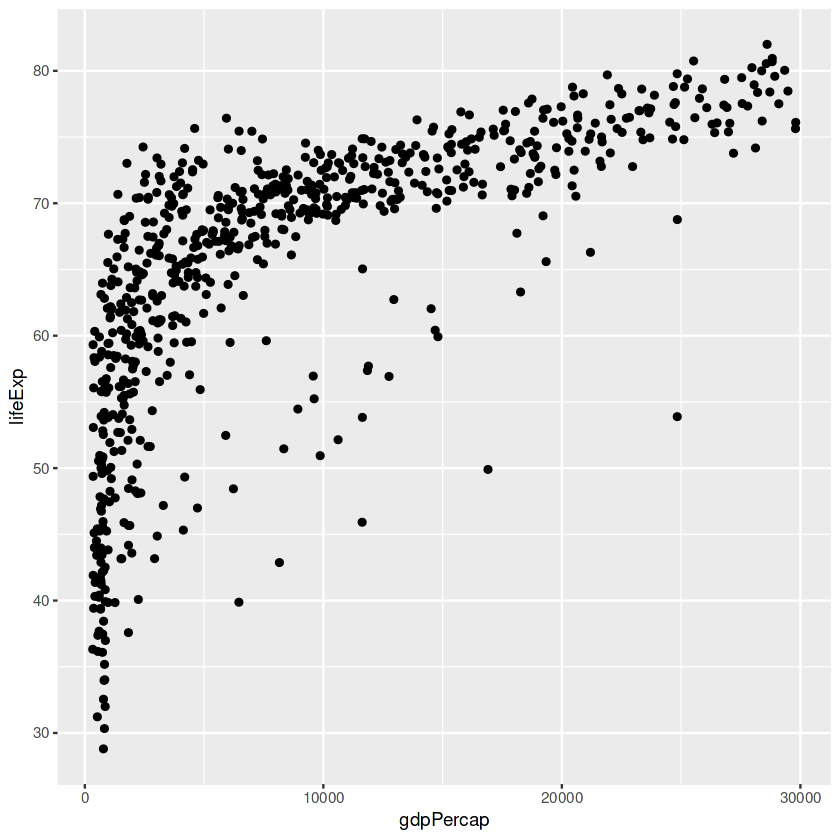

In [ ]:
gapminder %>%
  filter(continent %in% c("Asia", "Europe")) %>%
  filter(gdpPercap < 30000) %>%
  ggplot(aes(gdpPercap, lifeExp)) +
  geom_point()

#### ধাপ ২: সাইজ এবং রঙ (Size & Color)

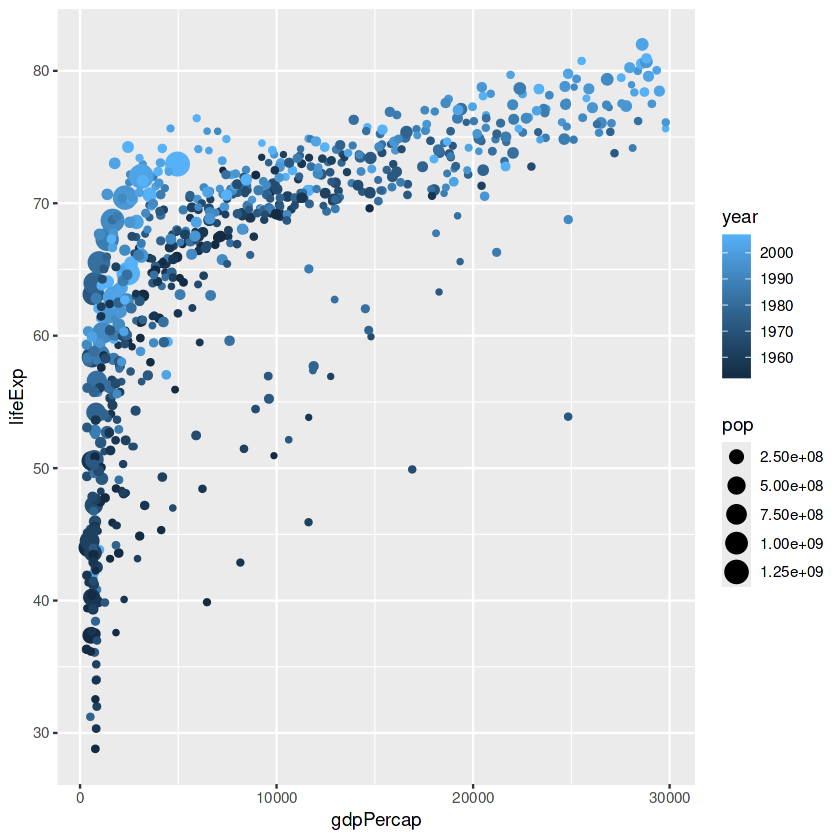

In [ ]:
gapminder %>%
  filter(continent %in% c("Asia", "Europe")) %>%
  filter(gdpPercap < 30000) %>%
  ggplot(aes(gdpPercap, lifeExp,
             size = pop,
             color = year)) +
  geom_point()

#### ধাপ ৩: লেবেল যোগ করা

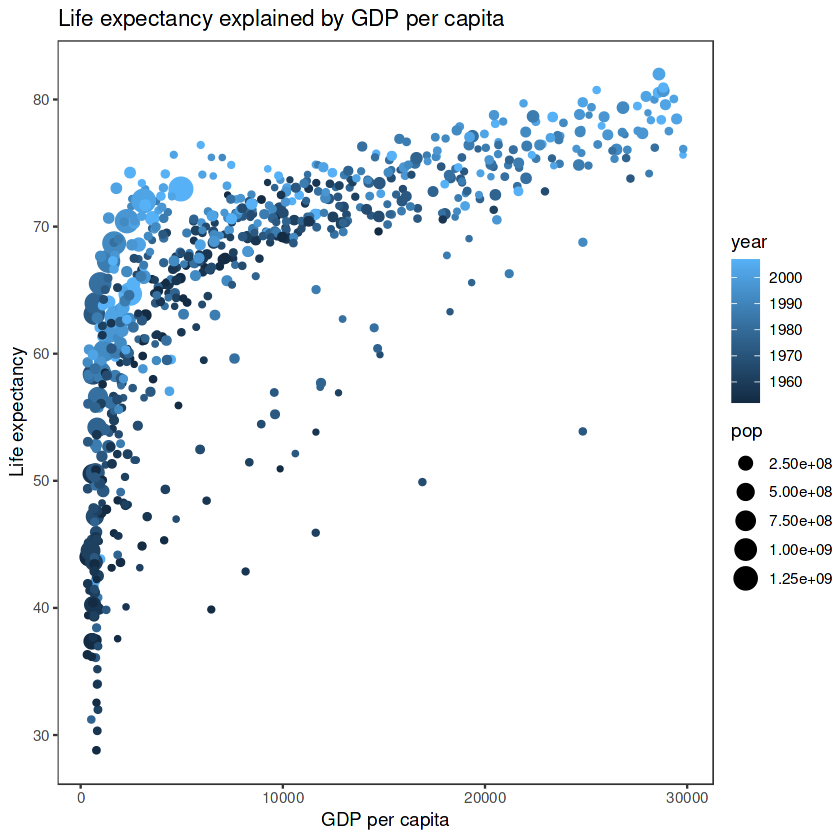

In [ ]:
gapminder %>%
  filter(continent %in% c("Asia", "Europe")) %>%
  filter(gdpPercap < 30000) %>%
  ggplot(aes(gdpPercap, lifeExp,
             size = pop,
             color = year)) +
  geom_point() +
  theme_test() +
  labs(title = "Life expectancy explained by GDP per capita",
       x = "GDP per capita",
       y = "Life expectancy")

#### ধাপ ৪: কালার প্যালেট ব্যবহার

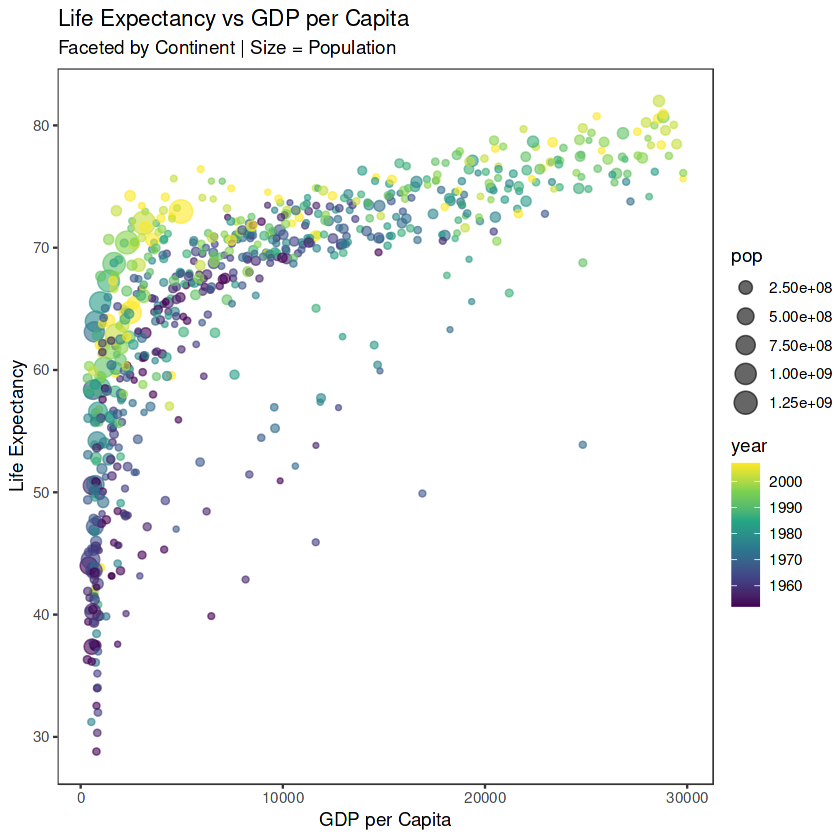

In [ ]:
gapminder %>%
  filter(continent %in% c("Asia", "Europe"), gdpPercap < 30000) %>%
  ggplot(aes(x = gdpPercap, y = lifeExp, size = pop, color = year)) +
  geom_point(alpha = 0.6) +
  theme_test() +
  scale_color_viridis_c() + # সুন্দর কালার গ্রেডিয়েন্ট
  labs(title = "Life Expectancy vs GDP per Capita",
       subtitle = "Faceted by Continent | Size = Population",
       x = "GDP per Capita",
       y = "Life Expectancy")

#### ধাপ ৫: ফেস্টিং (Faceting)

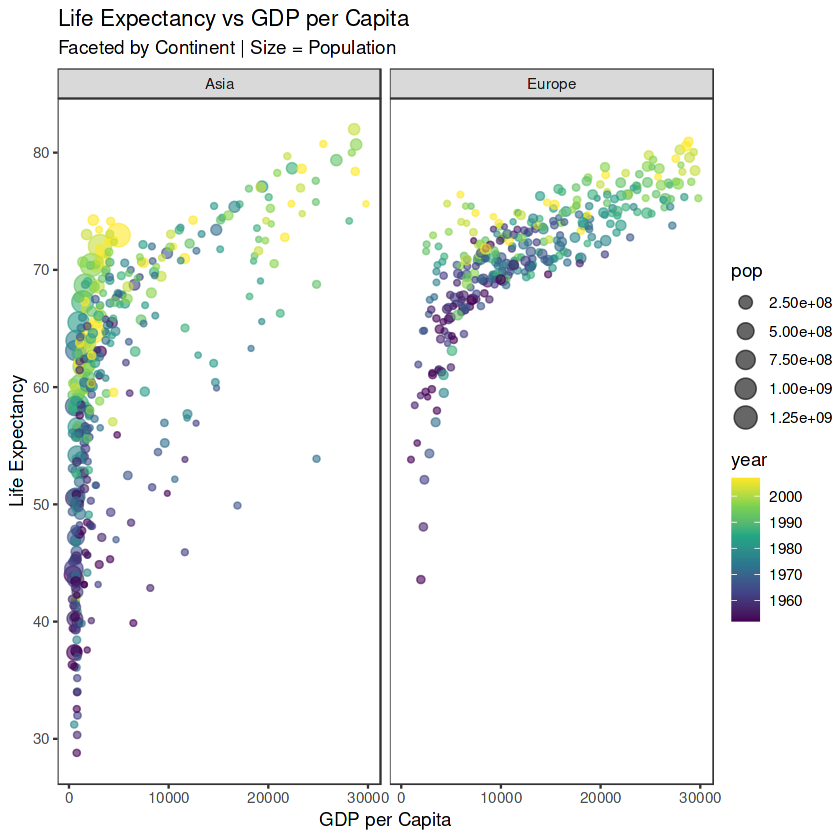

In [ ]:
gapminder %>%
  filter(continent %in% c("Asia", "Europe"), gdpPercap < 30000) %>%
  ggplot(aes(x = gdpPercap, y = lifeExp, size = pop, color = year)) +
  geom_point(alpha = 0.6) +
  theme_test() +
  scale_color_viridis_c() + # সুন্দর কালার গ্রেডিয়েন্ট
  labs(title = "Life Expectancy vs GDP per Capita",
       subtitle = "Faceted by Continent | Size = Population",
       x = "GDP per Capita",
       y = "Life Expectancy") +
  facet_wrap(~continent) # এশিয়া ও ইউরোপের জন্য আলাদা প্যানেল

### **এক নজরে আপনার টুলকিট (Cheat Sheet):**

* **`aes()`**: গ্রাফের কঙ্কাল (Skeleton) তৈরি করে।
* **`geom_***()`**: গ্রাফের মাংসপেশি বা দৃশ্যমান অংশ তৈরি করে।
* **`facet_wrap()`**: বড় গ্রাফকে ছোট ছোট অর্থবহ ভাগে ভাগ করে।
* **`theme_***()`**: গ্রাফকে দৃষ্টিনন্দন বা প্রফেশনাল করে তোলে।

---

**চমৎকার একটি গাইড!** আপনি এখন `ggplot2` এর মাধ্যমে ডেটা ভিজ্যুয়ালাইজেশনের বেসিক থেকে ইন্টারমিডিয়েট লেভেলের সবকটি ধাপ আয়ত্ত করেছেন।